**Programmer:** python_scripts (Abhijith Warrier)

**PYTHON SCRIPT TO _SELECT IMPORTANT FEATURES USING MUTUAL INFORMATION FOR MACHINE LEARNING_. ⚡️🧠📊**

This script demonstrates how to use **Mutual Information (MI)** to measure the relationship between features and the target variable, helping us identify the most informative features for model training.

---

## **📦 Import Required Libraries**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

---

## **🧩 Load Dataset**

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

---

## **✂️ Split Data**

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

---

## **🚨 Baseline Model (All Features)**

In [4]:
baseline_model = RandomForestClassifier(random_state=42)

baseline_model.fit(X_train, y_train)

baseline_pred = baseline_model.predict(X_test)

print("Baseline Accuracy:", accuracy_score(y_test, baseline_pred))

Baseline Accuracy: 0.935672514619883


---

## **🧠 Compute Mutual Information Scores**

Mutual Information measures how much information a feature provides about the target.

In [5]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MI Score": mi_scores
})

mi_df = mi_df.sort_values(by="MI Score", ascending=False)

print(mi_df)

                    Feature  MI Score
22          worst perimeter  0.480169
27     worst concave points  0.458544
20             worst radius  0.456132
23               worst area  0.453980
7       mean concave points  0.441150
2            mean perimeter  0.408863
0               mean radius  0.366090
6            mean concavity  0.361105
3                 mean area  0.355582
26          worst concavity  0.335338
13               area error  0.332560
5          mean compactness  0.255189
25        worst compactness  0.251395
10             radius error  0.224313
12          perimeter error  0.223516
16          concavity error  0.160363
21            worst texture  0.151694
17     concave points error  0.127961
1              mean texture  0.121856
28           worst symmetry  0.089927
24         worst smoothness  0.083642
4           mean smoothness  0.076313
11            texture error  0.057833
15        compactness error  0.047041
8             mean symmetry  0.046631
29  worst fr

---

## **📊 Visualise Feature Importance**

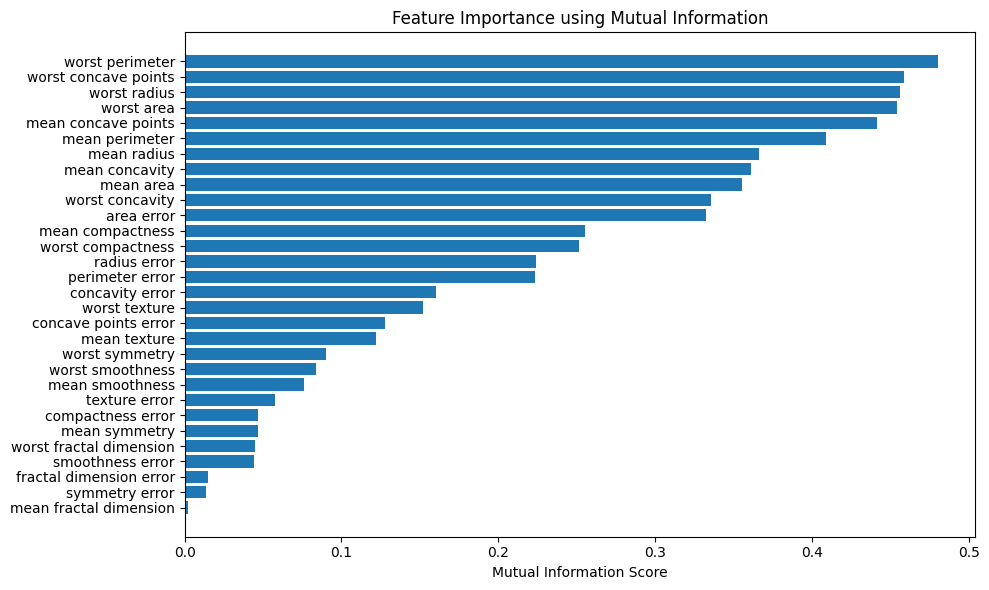

In [6]:
plt.figure(figsize=(10, 6))

plt.barh(mi_df["Feature"], mi_df["MI Score"])

plt.xlabel("Mutual Information Score")
plt.title("Feature Importance using Mutual Information")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

---

## **🔍 Select Top Features**

We keep only the most informative features.

In [7]:
top_features = mi_df["Feature"].head(10).tolist()

X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

---

## **🤖 Train Model with Selected Features**

In [8]:
selected_model = RandomForestClassifier(random_state=42)

selected_model.fit(X_train_selected, y_train)

selected_pred = selected_model.predict(X_test_selected)

print("Selected Features Accuracy:", accuracy_score(y_test, selected_pred))

Selected Features Accuracy: 0.9415204678362573


---

## **🔍 Why Feature Selection Matters**

Feature selection helps by:

- reducing noise
- improving training speed
- simplifying models
- improving interpretability
- reducing overfitting

Not all features contribute equally to prediction quality.

---

## **🧠 Key Takeaways**

1. Mutual Information measures dependency between features and target.
2. Higher MI score → more informative feature.
3. Feature selection can simplify models significantly.
4. Removing weak features may improve generalisation.
5. A powerful technique for tabular machine learning.

---

## **Conclusion**

Feature selection is an important step in building efficient and reliable machine learning systems. By using Mutual Information, we can identify the most useful features and focus the model on the strongest predictive signals.

This continues the **Feature Engineering** track in **Saturday ML Spark ⚡️**, helping you move beyond raw data into smarter feature design and selection.

---